# Use a MLP, feed encoded data into it

# 1. Build the MLP to predict transmission loss

## 1.1 Imports

In [131]:
import copy
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

import xarray as xr
from scipy.interpolate import RegularGridInterpolator, interp1d
from torch.utils.data import Dataset


## 1.2 Paths

In [80]:
# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()
DATA_PATH = os.path.join(HERE, "Data", "BellhopData", "bellhop_monthly_original.csv")
MODEL_PATH = os.path.join(HERE, "Data", "BellhopData", "tl_residual_xgb_model.joblib")
IMPORTANCE_PATH = os.path.join(HERE, "Data", "BellhopData", "tl_residual_xgb_importance.csv")
FIG_DIR = os.path.join(HERE, "Figures")


## 1.3 Feature lists

In [81]:
# ── Features (XGBoost handles NaN natively; only `layer` needs encoding), hmmmmmmmm
NUMERIC = [
    "range_km", "log10_freq_hz",
    "src_seabed_depth_m", "rcv_seabed_depth_m",
    "path_min_depth_m", "path_mean_depth_m",
    "src_depth_m", "rcv_depth_m", "layer_mean_speed_ms",
]
BINARY = ["is_shadow", "month_sin", "month_cos"]
CATEGORICAL = ["layer"]
FEATURES = BINARY + NUMERIC + CATEGORICAL

## 1.4 MLP HYPEperparams

Deifne atchitecture: layers, sizes, activations
#
Define loss function
#
Define optimizer
#
Loop: 

In [ ]:
HIDDEN = (128, 64, 32)  #size of the 3 hidden layers
DROPOUT = 0.3   #DROPOUT of units randomly zeroed each forward pass, reduce overfitting
BATCH_SIZE = 256    #rows per grafient step
LR = 1e-3   #learnong rate
WEIGHT_DECAY = 1e-5 #
N_EPOCHS = 500  #maximum epochs
PATIENCE = 20   #early stopping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   


#encoder huyperparameters:
N_POINTS = 100              #every depth profile gets resampled to this many points, same as the old autoencoder notebook
LATENT_DIM = 8               #size of the encoder's output vector — same choice as before, but now feeds the MLP directly, not a decoder
CONV_FILTERS = 5             #number of local pattern detectors the Conv1d layer learns
CONV_KERNEL = 9              #how many neighbouring depth points each detector looks at


## 1.5 LOad And Prepare DataFrame

In [152]:
def load_and_prepare() -> tuple[pd.DataFrame, list[str]]:
    """Load the dataset, drop Bellhop artifacts, add target + engineered
    features, and merge in the autoencoder embeddings by group_id."""
    df = pd.read_csv(DATA_PATH)
    valid = (df["tl_bellhop_db"].notna() & np.isfinite(df["tl_bellhop_db"])
             & (df["tl_bellhop_db"] <= 160.0))
    print(f"Loaded {len(df)} rows; dropped {(~valid).sum()} invalid Bellhop values "
          f"-> {valid.sum()} remain")
    df = df[valid].copy()

    df["residual_db"] = df["tl_bellhop_db"] - df["tl_analytic_db"]
    df["log10_freq_hz"] = np.log10(df["freq_hz"])
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["is_shadow"] = (df["shadow_penalty_db"] > 0).astype(float)

    if "group_id" not in df.columns:
        df["group_id"] = df["source_file"].astype(str) + "_" + df["pair_i"].astype(str)
    return df

## 1.6 Load tha data

In [153]:
df = load_and_prepare()
df.head()

Loaded 23968 rows; dropped 864 invalid Bellhop values -> 23104 remain


,pair_i,src_lat,src_lon,rcv_lat,rcv_lon,bearing_deg,range_km,src_seabed_depth_m,rcv_seabed_depth_m,path_min_depth_m,...,shadow_penalty_db,tl_analytic_db,tl_bellhop_db,source_file,residual_db,log10_freq_hz,month_sin,month_cos,is_shadow,group_id
0,0,62.944287,-31.396932,64.608031,-32.944677,338.346241,200.00636,2571.527633,1975.187583,1975.199909,...,0.0,100.186,90.910850,bellhop_long_range_Apr.csv,-9.275150,2.000000,0.866025,-0.5,0.0,bellhop_long_range_Apr.csv_0
1,0,62.944287,-31.396932,64.608031,-32.944677,338.346241,200.00636,2571.527633,1975.187583,1975.199909,...,0.0,100.522,90.804406,bellhop_long_range_Apr.csv,-9.717594,2.477121,0.866025,-0.5,0.0,bellhop_long_range_Apr.csv_0
2,0,62.944287,-31.396932,64.608031,-32.944677,338.346241,200.00636,2571.527633,1975.187583,1975.199909,...,0.0,103.444,100.359049,bellhop_long_range_Apr.csv,-3.084951,3.000000,0.866025,-0.5,0.0,bellhop_long_range_Apr.csv_0
3,0,62.944287,-31.396932,64.608031,-32.944677,338.346241,200.00636,2571.527633,1975.187583,1975.199909,...,0.0,121.893,126.336227,bellhop_long_range_Apr.csv,4.443227,3.477121,0.866025,-0.5,0.0,bellhop_long_range_Apr.csv_0
4,0,62.944287,-31.396932,64.608031,-32.944677,338.346241,200.00636,2571.527633,1975.187583,1975.199909,...,0.0,97.186,92.799324,bellhop_long_range_Apr.csv,-4.386676,2.000000,0.866025,-0.5,0.0,bellhop_long_range_Apr.csv_0


## 1.7 Preprocessing Pipeline
'XGBoost handles NaNs natively'


In [154]:
def make_preprocessor() -> ColumnTransformer:
    """Median-impute + standardize numeric features, one-hot encode `layer`,
    pass the already-bounded binary/cyclical features through untouched."""
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),   #fill NaNs (e.g. missing path_min_depth_m) with the train-set median
        ("scale", StandardScaler()),                    #zero-mean/unit-variance scale, since raw ranges differ wildly (km vs m vs m/s)
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, NUMERIC),                                              #numeric columns go through impute+scale
        ("bin", "passthrough", BINARY),                                              #binary/cyclical columns are left as-is
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),  #one-hot encode `layer`
    ])

## 1.8 Define MLP architecture

In [155]:
class MLP(nn.Module):   #define MLP as a class of nn.Module. MLP automatically gets .parameters hooks into autograd
    def __init__(self, n_features: int, hidden = HIDDEN, dropout = DROPOUT):   #construcotr, sets up the layers
        super().__init__()     #calls nn.Modules cinstructor
        layers = [] #will hold each layer of the network in order then handed to nn.Sequential afterwards
        in_dim = n_features     #initialises a running counter representing how many layers go into the next layer. Strarts equal to the size of the raw input vecotr, because the very fitst layer takes the raw features as inputs
        for h in hidden:  #loop runs once per hidden layer (if [64, 32] then ones 64 times then 32 times)
            layers += [     #list concatention. same as writing layers.append(nn.Linear); layers.append(nn.ReLU); etc
                nn.Linear(in_dim, h), #creates one fully connected layer object. When this objec5 is constructed PyTorch allocates: A weight matrix of shape (h, in_dim)-initialised to small random values. A basis vector of length h- also intialised to small random values or 0
                nn.ReLU(), #activation unit object. allawus non linear relationships to be learnt
                nn.Dropout(dropout)] #dropout that prevents overfitting
            in_dim  = h     #after builidng hidden block, update the running counter: the next layers input size must equal this layers output size, h.
        layers.append(nn.Linear(in_dim, 1))  #final output layer, in_dim holds the final hidden size, output dimesnion is
        self.net = nn.Sequential(*layers)      #assembling the chain: 

    def forward(self, x):  #defines what happens tp input x
        return self.net(x).squeeze(-1) #self.net(x)

## 1.9 Wrap Arrays in DataLoader

In [156]:
def _to_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),    #feature matrix as a float32 tensor
                        torch.tensor(y, dtype=torch.float32))   #target vector as a float32 tensor
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)  # atches the dataset, shuffling only for training

## 1.11 Training Loop with early stopping

In [157]:
def train_mlp(X_train, y_train, X_val, y_val) -> MLP:
    train_loader = _to_loader(X_train, y_train, BATCH_SIZE, shuffle=True)   #training batches, shuffled each epoch
    val_loader = _to_loader(X_val, y_val, BATCH_SIZE, shuffle=True)        #validation batches, shuffle shouldnt matter

    model = MLP(X_train.shape[1]).to(device)                               #build the network sized to the number of input features
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)  #Adam optimizer with weight decay
    criterion = nn.MSELoss()                                                #mean squared error loss, since this is regression

    train_losses, val_losses = [], []          #tracks loss per epoch, for the training-curve plot
    best_val_loss = float("inf")               #best validation loss seen so far
    best_state = None                          #smapshot of the model weights at the best epoch
    epochs_no_improve = 0                      #counts epochs since the last improvement, for early stopping

    for epoch in range(N_EPOCHS):              #loop over epochs, up to maximum set
        model.train()                          # witch to training mode (enables dropout)
        train_loss = 0.0                       #accumulate this epochs training loss
        for xb, yb in train_loader:             #iterate over training batches
            xb, yb = xb.to(device), yb.to(device)   #move batch to the training device
            optimizer.zero_grad()               #clear gradients from the previous step
            loss = criterion(model(xb), yb)     #forward pass + compute the loss
            loss.backward()                     #backpropagate gradients
            optimizer.step()                    #update the weights
            train_loss += loss.item() * xb.size(0)  #accumulate loss weighted by batch size
        train_loss /= len(train_loader.dataset)     #average over all training rows

        model.eval()                            #switch to eval mode (disables dropout)
        val_loss = 0.0                          #accumulate this epochs validation loss
        with torch.no_grad():                   #no need to track gradients for validation
            for xb, yb in val_loader:            #iterate over validation batches
                xb, yb = xb.to(device), yb.to(device)   #move batch to the training device
                val_loss += criterion(model(xb), yb).item() * xb.size(0)  #accumulate loss weighted by batch size
        val_loss /= len(val_loader.dataset)      #average over all validation rows

        train_losses.append(train_loss)          #record this epochs training loss
        val_losses.append(val_loss)              #record this epochs validation loss


        #early stopping
        if val_loss < best_val_loss:             #did validation loss improve
            best_val_loss = val_loss             #update the best-seen loss
            best_state = copy.deepcopy(model.state_dict())  #snapshot the weights at this (best) epoch
            epochs_no_improve = 0                #reset the no-improvement counter
        else:
            epochs_no_improve += 1             #one more epoch without improvement
            if epochs_no_improve >= PATIENCE:    #give up once patience is exhausted
                print(f"Early stopping at epoch {epoch + 1} "
                      f"(no improvement for {PATIENCE} epochs, best val loss: {best_val_loss:.4f})")
                break                             #stop training early

    model.load_state_dict(best_state)            #restore the weights from the best epoch, not the last one
    print(f"Restored best model with val loss: {best_val_loss:.4f}")
    _plot_training_curve(train_losses, val_losses)  #plot how train/val loss evolved
    return model                                  #hand back the trained model




# 1.12 Plot Training Curve

In [158]:
def _plot_training_curve(train_losses, val_losses) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))         #new figure for the loss curve
    ax.plot(train_losses, label="Train")            #training loss per epoch
    ax.plot(val_losses, label="Val")                 #validation loss per epoch
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss (scaled target)")  #axis labels
    ax.set_yscale("log"); ax.legend()                #log scale makes early/late-epoch changes both visible
    ax.set_title("MLP training curve")               #pplot title
    fig.tight_layout()                               
    # fig.savefig(os.path.join(FIG_DIR, "mlp_training_curve.png"), dpi=150)  #save 
    print(f"Saved {os.path.join(FIG_DIR, 'mlp_training_curve.png')}")       

## 1.13 Predictions and metrics

In [159]:
def predict_db(model: MLP, X: np.ndarray, y_mean: float, y_std: float) -> np.ndarray:
    model.eval()                                     #eval mode (disables dropout) for inference
    with torch.no_grad():                            #no gradients needed for prediction
        preds_scaled = model(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy()  #run the model, bring result back to numpy
    return preds_scaled * y_std + y_mean              #undo the target standardization, back to dB units

def _metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str) -> None:
    print(f"  {label:6s} R2={r2_score(y_true, y_pred):.4f}  "             #R2
          f"RMSE={mean_squared_error(y_true, y_pred) ** 0.5:.3f} dB  "    #root mean squared error, in dB
          f"MAE={mean_absolute_error(y_true, y_pred):.3f} dB")            #mean absolute error, in dB

## 1.14 Feature Importance - XGBoost has this built in 

In [160]:
def feature_importance(model, X, y_true_db, y_mean, y_std, feature_names, n_repeats=5, seed=0):
    """Shuffle one (encoded) column at a time; importance = RMSE increase."""
    rng = np.random.default_rng(seed)                                          #reproducible random shuffling
    baseline_rmse = mean_squared_error(y_true_db, predict_db(model, X, y_mean, y_std)) ** 0.5  #RMSE with all features intact

    importances = []                                    #will hold one importance score per feature
    for j in range(X.shape[1]):                          #loop over each column (feature) of the preprocessed matrix
        increases = []                                    #RMSE increase from shuffling this column, repeated a few times
        for _ in range(n_repeats):                        #repeat to average out shuffle noise
            X_perm = X.copy()                             #work on a copy so the original data isn't mutated
            rng.shuffle(X_perm[:, j])                      #shuffle just this one column, breaking its relationship with y
            pred = predict_db(model, X_perm, y_mean, y_std)  #predict with the shuffled feature
            rmse = mean_squared_error(y_true_db, pred) ** 0.5   #RMSE with that feature scrambled
            increases.append(rmse - baseline_rmse)          #how much worse did predictions get?
        importances.append(np.mean(increases))              #average increase = importance of this feature

    return pd.DataFrame({"feature": feature_names, "importance": importances}) \
        .sort_values("importance", ascending=False)          #most important feature first

## 1.15 Grouped train/val/test split

In [161]:
X_df, y, groups = df[FEATURES], df["residual_db"].values, df["group_id"]   #feature frame, target array, and grouping key

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)  #80/20 split, same as fit_xgb.py
trainfull_idx, test_idx = next(gss_test.split(X_df, y, groups=groups))     #indices for train+val vs held-out test

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)  #0.125 of the 80% = 10% of the whole dataset
train_idx_rel, val_idx_rel = next(gss_val.split(
    X_df.iloc[trainfull_idx], y[trainfull_idx], groups=groups.iloc[trainfull_idx]))  #split train+val further, by group
train_idx, val_idx = trainfull_idx[train_idx_rel], trainfull_idx[val_idx_rel]         #map back to original row indices

print(f"Train: {len(train_idx)} rows, {groups.iloc[train_idx].nunique()} pairs")   #sanity-check split sizes
print(f"Val:   {len(val_idx)} rows, {groups.iloc[val_idx].nunique()} pairs")
print(f"Test:  {len(test_idx)} rows, {groups.iloc[test_idx].nunique()} pairs")

Train: 16210 rows, 2163 pairs
Val:   2365 rows, 310 pairs
Test:  4529 rows, 619 pairs


## 1.16 Fit the preprocessor on train only, transform all 3 splits

In [162]:
pre = make_preprocessor()                          #build a fresh (unfitted) preprocessing pipeline
X_train = pre.fit_transform(X_df.iloc[train_idx])  #fit imputer/scaler/encoder on train, then transform train
X_val = pre.transform(X_df.iloc[val_idx])           #transform val using the train-fitted preprocessor (no leakage)
X_test = pre.transform(X_df.iloc[test_idx])         #transform test the same way
feature_names = pre.get_feature_names_out()         #column names after one-hot expansion, for the importance table

y_mean, y_std = y[train_idx].mean(), y[train_idx].std()   #target scaling stats, computed on train only
y_train_s = (y[train_idx] - y_mean) / y_std                #standardized training target
y_val_s = (y[val_idx] - y_mean) / y_std                     #standardized validation target


## 1.17 Train the MLP


Training MLP...
Early stopping at epoch 43 (no improvement for 20 epochs, best val loss: 0.2921)
Restored best model with val loss: 0.2921
Saved /Users/jhughes/Desktop/transmission-loss/Figures/mlp_training_curve.png


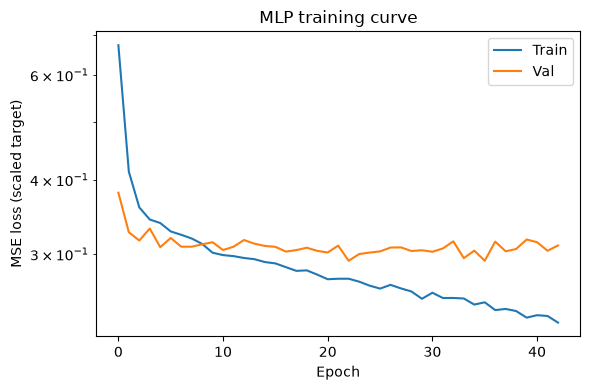

In [163]:
print("\nTraining MLP...")
model = train_mlp(X_train, y_train_s, X_val, y_val_s) #run trianing loop + return best epoch loop

## 1.18 Evaluate on train/test

In [168]:
print("Performance:")
_metrics(y[train_idx], predict_db(model, X_train, y_mean, y_std), "train")  #training-set metrics
_metrics(y[test_idx], predict_db(model, X_test, y_mean, y_std), "test")      #held-out test metrics

Performance:
  train  R2=0.7592  RMSE=5.501 dB  MAE=3.392 dB
  test   R2=0.6991  RMSE=6.196 dB  MAE=3.725 dB


## 1.19 Feature Importance

                 feature  importance
           num__range_km    3.674142
          bin__is_shadow    3.462720
   num__path_min_depth_m    2.019232
 num__rcv_seabed_depth_m    2.018578
        num__src_depth_m    1.602411
 num__src_seabed_depth_m    1.401225
  num__path_mean_depth_m    1.149272
      num__log10_freq_hz    1.146677
          bin__month_sin    0.995464
          bin__month_cos    0.893018
      cat__layer_surface    0.815378
num__layer_mean_speed_ms    0.344215
         cat__layer_deep    0.288858
          cat__layer_mid    0.190140
        num__rcv_depth_m    0.000000
Saved /Users/jhughes/Desktop/transmission-loss/Data/BellhopData/tl_residual_xgb_importance.csv


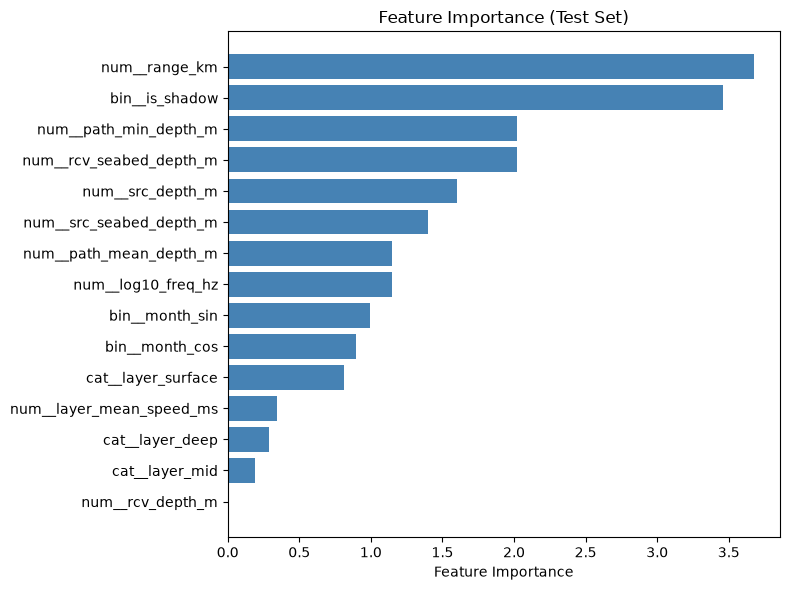

In [169]:
imp = feature_importance(model, X_test, y[test_idx], y_mean, y_std, feature_names)  #compute importances on the test set
print(imp.to_string(index=False))                          #print the full table
print(f"Saved {IMPORTANCE_PATH}")

#Plot featurre importance
imp_sorted = imp.sort_values('importance', ascending=True)  #ascending so biggest bar is on top

plt.figure(figsize=(8, max(4, 0.4 * len(imp_sorted))))
plt.barh(imp_sorted['feature'], imp_sorted['importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance (Test Set)')
plt.tight_layout()
plt.show()

## 1.21 Save the model + preprocessor

In [170]:
torch.save(model.state_dict(), MODEL_PATH)                    #save just the learned weights
joblib.dump({"preprocessor": pre, "y_mean": y_mean, "y_std": y_std,   # ave everything needed to preprocess new data...
             "hidden": HIDDEN, "n_features": X_train.shape[1]}, PREPROC_PATH)  # ...and rebuild the same architecture at load time
print(f"Saved model -> {MODEL_PATH}")
print(f"Saved preprocessor -> {PREPROC_PATH}")

Saved model -> /Users/jhughes/Desktop/transmission-loss/Data/BellhopData/tl_residual_xgb_model.joblib
Saved preprocessor -> /Users/jhughes/Desktop/transmission-loss/Data/BellhopData/tl_residual_mlp_preprocessor.joblib


## 1,22 Actual Vs Predicted Plot

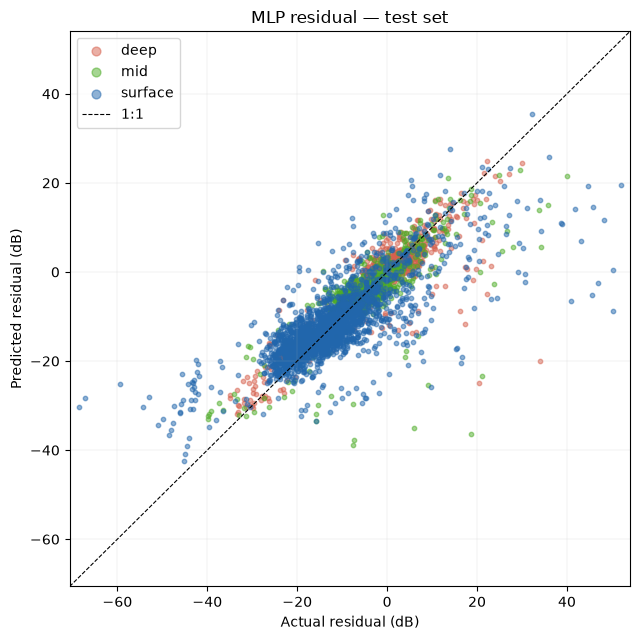

In [171]:
y_test_pred = predict_db(model, X_test, y_mean, y_std)   #predictions on the test set, in dB

colors = {"surface": "#2166ac", "mid": "#4dac26", "deep": "#d6604d"}   # one color per acoustic layer
df_test = df.iloc[test_idx].copy()                                     # test-set rows, for grouping by `layer`
df_test["_pred"] = y_test_pred                                         # attach predictions for plotting

fig, ax = plt.subplots(figsize=(6.5, 6.5))                             # square figure for a 1:1 comparison
for layer, grp in df_test.groupby("layer"):                            # one scatter series per layer
    ax.scatter(grp["residual_db"], grp["_pred"], s=10, alpha=0.5,
               color=colors.get(layer, "gray"), label=layer)           # actual vs predicted for this layer
lims = [min(y[test_idx].min(), y_test_pred.min()) - 2,
        max(y[test_idx].max(), y_test_pred.max()) + 2]                 # shared axis limits with a small margin
ax.plot(lims, lims, "k--", lw=0.8, label="1:1")                        # reference line for a perfect prediction
ax.set_xlim(lims); ax.set_ylim(lims)                                   # square, matching axes
ax.set_xlabel("Actual residual (dB)"); ax.set_ylabel("Predicted residual (dB)")  # axis labels
ax.set_title("MLP residual — test set"); ax.legend(markerscale=2)      # title + legend
ax.grid(True, lw=0.3, alpha=0.4)                                       # light gridlines
fig.tight_layout()                                                      # avoid clipped labels
plt.show()  

## 2. Encode Seabed FLoor
Build the same COnvoloutional encoder but this time build to go into the MLP not for reconstrction


# 2.1 Load Bathymetry Data

In [172]:
f_bathy = '/Users/jhughes/Downloads/GEBCO_14_Aug_2026_8d63a979c142/gebco_2026_n69.06_s62.94_w-41.46_e-16.03.nc'
data_xr = xr.open_dataset(f_bathy) #returns an xarray, contains a lat, long and elevation value for each point
print(data_xr)
print(data_xr.sizes)
#this is the data the autoencoder will use, elevation will be x

<xarray.Dataset> Size: 36MB
Dimensions:    (lat: 1468, lon: 6103)
Coordinates:
  * lat        (lat) float64 12kB 62.94 62.95 62.95 62.96 ... 69.05 69.05 69.06
  * lon        (lon) float64 49kB -41.46 -41.45 -41.45 ... -16.04 -16.04 -16.03
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) float32 36MB ...
Attributes: (12/37)
    comment:                         The data in the GEBCO_2026 Grid should n...
    Conventions:                     CF-1.6, ACDD-1.3
    creator_email:                   gdacc@seabed2030.org
    creator_name:                    GEBCO through the Nippon Foundation-GEBC...
    creator_type:                    International organisation
    creator_url:                     https://www.gebco.net
    ...                              ...
    project:                         Nippon Foundation - GEBCO Seabed2030 Pro...
    references:                      DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    source:                          The GEBCO_2026 Grid

## Extract Arrays

In [173]:
#define latitude, longitude, elevation, print the shape of lat, long and elevation
lat = np.asarray(data_xr['lat'])   #pulls the lat coordiante out of the dataset, converts it into a numpy array. shape = 1200
lon = np.asarray(data_xr['lon'])   #puls the long coordiantes out of the data and converts it to a numoy array. shape - 2400
elevation = np.asarray(data_xr['elevation'])   #puls the elevation coordiantes out of the data and 2D grid(one row per long & lat) it to a numoy array. shape - 1200, 2400
print(f'Latitude shape: {lat.shape}')
print(f'Longitude shape: {lon.shape}')
print(f'Elevation shape: {elevation.shape}')

# --- Mask land (elevation > 0), keep only ocean depths ---
elevation_masked = np.ma.masked_where(elevation > 0, elevation)  #a new array, same shape as elevation. where elevation>0 is hidden

Latitude shape: (1468,)
Longitude shape: (6103,)
Elevation shape: (1468, 6103)


## Load Source Reciever PAths & build Path_sampling

In [174]:
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()
DATA_PATH = os.path.join(HERE, "Data", "BellhopData", "bellhop_monthly_original.csv") #

def load_and_prepare() -> pd.DataFrame:  
    df = pd.read_csv(DATA_PATH)
    valid = (df["tl_bellhop_db"].notna() & np.isfinite(df["tl_bellhop_db"])
             & (df["tl_bellhop_db"] <= 160.0))
    df = df[valid].copy()

    df["residual_db"] = df["tl_bellhop_db"] - df["tl_analytic_db"]
    df["log10_freq_hz"] = np.log10(df["freq_hz"])
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    if "group_id" not in df.columns:
        df["group_id"] = df["source_file"].astype(str) + "_" + df["pair_i"].astype(str)
    return df

df = load_and_prepare()

# One row per unique source-receiver pair (the same pair repeats across freq_hz/month)
path_table = (
    df[['group_id', 'src_lat', 'src_lon', 'rcv_lat', 'rcv_lon', 'range_km']]
    .drop_duplicates(subset='group_id')
    .reset_index(drop=True)
)
print(f"{len(path_table)} unique source-receiver paths in the dataset")

def initial_bearing(lat1, lon1, lat2, lon2):  #computes compass bearing betweeen the points and store as path_table
    """Initial great-circle compass bearing (deg, 0=N, clockwise) from point 1 to point 2."""
    lat1_r, lat2_r = np.radians(lat1), np.radians(lat2)
    dlon_r = np.radians(lon2 - lon1)
    x = np.sin(dlon_r) * np.cos(lat2_r)
    y = np.cos(lat1_r) * np.sin(lat2_r) - np.sin(lat1_r) * np.cos(lat2_r) * np.cos(dlon_r)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

path_table['bearing_deg'] = initial_bearing(
    path_table['src_lat'].values, path_table['src_lon'].values,
    path_table['rcv_lat'].values, path_table['rcv_lon'].values,
)

def sample_paths_from_table(path_table, lat, lon, elevation, step_m=500):
    """
    Sample depth profiles along the ACTUAL source-receiver paths in path_table
    (one path per unique group_id) — same stepping/interpolation as before,
    but the start point, bearing, and length all come from real data.
    """
    R_EARTH = 6371000.0
    interp = RegularGridInterpolator((lat, lon), elevation, bounds_error=False, fill_value=np.nan)

    def destination_point(lat0, lon0, bearing_deg, distance_m):
        lat0_r, lon0_r = np.radians(lat0), np.radians(lon0)
        brng = np.radians(bearing_deg)
        d_r = distance_m / R_EARTH
        lat1_r = np.arcsin(np.sin(lat0_r) * np.cos(d_r) + np.cos(lat0_r) * np.sin(d_r) * np.cos(brng))
        lon1_r = lon0_r + np.arctan2(
            np.sin(brng) * np.sin(d_r) * np.cos(lat0_r),
            np.cos(d_r) - np.sin(lat0_r) * np.sin(lat1_r)
        )
        return np.degrees(lat1_r), np.degrees(lon1_r)

    paths, coords, group_ids = [], [], []
    for row in path_table.itertuples(index=False):
        length_m = row.range_km * 1000
        n_steps = int(length_m // step_m) + 1
        if n_steps < 2:
            continue

        distances = np.arange(n_steps) * step_m
        lat_pts = np.empty(n_steps)
        lon_pts = np.empty(n_steps)
        for i, d in enumerate(distances):
            lat_pts[i], lon_pts[i] = destination_point(row.src_lat, row.src_lon, row.bearing_deg, d)

        depths = interp(np.column_stack([lat_pts, lon_pts]))
        paths.append(depths)
        coords.append((lat_pts, lon_pts))
        group_ids.append(row.group_id)

    return paths, coords, group_ids

def drop_nan_paths(paths, ids):
    keep = [i for i, p in enumerate(paths) if not np.any(np.isnan(p)) and not np.any(p > 0)]
    dropped = len(paths) - len(keep)
    if dropped:
        print(f"Dropped {dropped} paths that left the bathymetry grid / crossed land")
    return [paths[i] for i in keep], [ids[i] for i in keep]


#Generate the paths:
demo_table = path_table.sample(n=35, random_state=10).reset_index(drop=True)  #for the plot
paths, coords, ids_demo = sample_paths_from_table(demo_table, lat, lon, elevation)


3092 unique source-receiver paths in the dataset


## Depth profile dataset class

In [175]:
class DepthProfileDataset(Dataset):
    def __init__(self, paths, n_points=100, mean=None, std=None):
        self.n_points = n_points
        clean_paths = [np.asarray(p) for p in paths if not np.any(np.isnan(p))]
        if len(clean_paths) < len(paths):
            print(f"Dropped {len(paths) - len(clean_paths)} paths containing NaNs.")

        resampled = np.array([self._resample(p, n_points) for p in clean_paths])
        self.trend = resampled.mean(axis=1, keepdims=True)
        detrended = resampled - self.trend

        if mean is None or std is None:
            self.mean = detrended.mean()
            self.std = detrended.std()
        else:
            self.mean = mean
            self.std = std

        normalized = (detrended - self.mean) / self.std
        self.data = torch.tensor(normalized, dtype=torch.float32)
        print(self.data.shape)
        self.trend = torch.tensor(self.trend, dtype=torch.float32)

    @staticmethod
    def _resample(depths, n_points):
        x_old = np.linspace(0, 1, len(depths))
        x_new = np.linspace(0, 1, n_points)
        f = interp1d(x_old, depths, kind='linear')
        return f(x_new)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx]
        return x, x

    def inverse_transform(self, x_normalized, idx=None, trend=None):
        if isinstance(x_normalized, torch.Tensor):
            x_normalized = x_normalized.detach().cpu().numpy()

        detrended = x_normalized * self.std + self.mean

        if trend is not None:
            if isinstance(trend, torch.Tensor):
                trend = trend.detach().cpu().numpy()
            trend_arr = np.asarray(trend)
        elif idx is not None:
            trend_arr = self.trend[idx].numpy()
        else:
            raise ValueError("Must provide either `idx` (to use stored trend) or `trend` explicitly.")

        return detrended + trend_arr


## Generate train/test/val path sets

In [176]:
train_groups = set(groups.iloc[train_idx])                          # group_ids assigned to train in Section 1's split
val_groups   = set(groups.iloc[val_idx])                            # same for val
test_groups  = set(groups.iloc[test_idx])                           # same for test

train_table = path_table[path_table['group_id'].isin(train_groups)].reset_index(drop=True)  # only paths whose group_id is a train group
val_table   = path_table[path_table['group_id'].isin(val_groups)].reset_index(drop=True)    # only paths whose group_id is a val group
test_table  = path_table[path_table['group_id'].isin(test_groups)].reset_index(drop=True)   # only paths whose group_id is a test group

paths_train, coords_train, ids_train = sample_paths_from_table(train_table, lat, lon, elevation)  # depth profiles for train paths
paths_val,   coords_val,   ids_val   = sample_paths_from_table(val_table,   lat, lon, elevation)  # depth profiles for val paths
paths_test,  coords_test,  ids_test  = sample_paths_from_table(test_table,  lat, lon, elevation)  # depth profiles for test paths

paths_train, ids_train = drop_nan_paths(paths_train, ids_train)     # drop any that left the grid / crossed land
paths_val,   ids_val   = drop_nan_paths(paths_val,   ids_val)
paths_test,  ids_test  = drop_nan_paths(paths_test,  ids_test)



Dropped 46 paths that left the bathymetry grid / crossed land
Dropped 7 paths that left the bathymetry grid / crossed land
Dropped 23 paths that left the bathymetry grid / crossed land


## Encoder Hyperparams

In [177]:
N_POINTS = 100          # every profile gets resampled to this many points before entering the encoder
LATENT_DIM = 8          # size of the encoder's output vector, same choice as the old reconstruction encoder
CONV_FILTERS = 5        # number of learned local depth-pattern detectors
CONV_KERNEL = 9         # how many neighbouring points each detector looks at


# Build group_id

In [178]:
def build_profile_lookup(paths, ids, n_points, mean=None, std=None):
    """Turn a list of raw depth profiles + their group_ids into a {group_id: tensor} lookup,
    using DepthProfileDataset's own resample/detrend/normalize logic."""
    ds = DepthProfileDataset(paths, n_points=n_points, mean=mean, std=std)   # reuses your existing preprocessing exactly
    # drop_nan_paths already removed anything with NaNs, so DepthProfileDataset's internal
    # NaN filter is a no-op here — ds.data lines up positionally with `ids`, one-to-one.
    lookup = {gid: ds.data[i] for i, gid in enumerate(ids)}                  # group_id -> normalized profile tensor (shape: n_points,)
    return lookup, ds.mean, ds.std                                          # hand back train's mean/std so val/test can reuse them

train_lookup, profile_mean, profile_std = build_profile_lookup(paths_train, ids_train, N_POINTS)                       # fit normalization on train
val_lookup,   _,            _           = build_profile_lookup(paths_val,   ids_val,   N_POINTS, profile_mean, profile_std)  # apply train's stats
test_lookup,  _,            _           = build_profile_lookup(paths_test,  ids_test,  N_POINTS, profile_mean, profile_std)  # apply train's stats


torch.Size([2117, 100])
torch.Size([303, 100])
torch.Size([596, 100])


# Drop rows with no profile

In [179]:
def filter_to_available(X, y_scaled, y_db, row_group_ids, lookup):
    """Keep only rows whose group_id survived path sampling / NaN-dropping."""
    keep = np.array([g in lookup for g in row_group_ids])            # boolean mask, True where a profile exists
    dropped = (~keep).sum()
    if dropped:
        print(f"Dropping {dropped} rows with no matching profile")
    return X[keep], y_scaled[keep], y_db[keep], row_group_ids[keep]

train_group_ids = df['group_id'].iloc[train_idx].values                          # group_id per training row, same order as X_train
val_group_ids   = df['group_id'].iloc[val_idx].values
test_group_ids  = df['group_id'].iloc[test_idx].values

X_train_j, y_train_sj, y_train_dbj, train_group_ids = filter_to_available(X_train, y_train_s, y[train_idx], train_group_ids, train_lookup)
X_val_j,   y_val_sj,   y_val_dbj,   val_group_ids   = filter_to_available(X_val,   y_val_s,   y[val_idx],   val_group_ids,   val_lookup)
X_test_j,  y_test_sj,  y_test_dbj,  test_group_ids  = filter_to_available(X_test,  y[test_idx][:0]*0 if False else y[test_idx], y[test_idx], test_group_ids, test_lookup)

Dropping 253 rows with no matching profile
Dropping 40 rows with no matching profile
Dropping 115 rows with no matching profile


## Joint dataset

In [180]:
class ResidualDataset(Dataset):
    """One item = (this row's depth profile, this row's tabular features, this row's target)."""
    def __init__(self, X_tabular, y_scaled, group_ids, lookup):
        self.X = torch.tensor(X_tabular, dtype=torch.float32)                  # tabular features, already preprocessed
        self.y = torch.tensor(y_scaled, dtype=torch.float32)                   # standardized target
        self.profiles = torch.stack([lookup[g] for g in group_ids])            # look up each row's profile by its group_id, stack into one tensor

    def __len__(self):
        return len(self.y)                                                     # one item per row, not per unique path

    def __getitem__(self, idx):
        return self.profiles[idx], self.X[idx], self.y[idx]                    # profile, tabular, target — matches EncoderMLP.forward's argument order


# Conv Encoder, 

In [181]:
class Encoder(nn.Module):
    def __init__(self, n_points, latent_dim, filters=CONV_FILTERS, neighbouring_points=CONV_KERNEL):
        super().__init__()
        padding = (neighbouring_points - 1) // 2                # keeps the conv's output length equal to its input length
        self.net = nn.Sequential(
            nn.Unflatten(1, (1, n_points)),                      # (batch, n_points) -> (batch, 1, n_points): Conv1d needs a channel dim
            nn.Conv1d(1, filters, neighbouring_points, padding=padding),  # learn `filters` local depth-shape detectors
            nn.ReLU(),
            nn.Flatten(),                                        # (batch, filters, n_points) -> (batch, filters * n_points)
            nn.Linear(filters * n_points, latent_dim),           # compress down to latent_dim numbers
        )

    def forward(self, profile):
        return self.net(profile)                                 # (batch, n_points) -> (batch, latent_dim)


# gets juicy- combined model: encoder feeds into MLP
reuses MLP from earlier

In [182]:
class EncoderMLP(nn.Module):
    def __init__(self, n_points, latent_dim, n_tabular_features, hidden=HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.encoder = Encoder(n_points, latent_dim)                          # the new, task-driven encoder
        self.head = MLP(n_features=n_tabular_features + latent_dim,           # the "new" MLP: same class as Section 1, wider input
                         hidden=hidden, dropout=dropout)

    def forward(self, profile, tabular):
        z = self.encoder(profile)                                             # (batch, latent_dim)
        combined = torch.cat([tabular, z], dim=1)                             # (batch, n_tabular_features + latent_dim)
        return self.head(combined)                                            # MLP.forward already squeezes to (batch,)


## Training loop + backprop

In [183]:
def train_encoder_mlp(train_ds, val_ds, n_tabular_features) -> EncoderMLP:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # each batch: (profiles, tabular, targets)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    model = EncoderMLP(N_POINTS, LATENT_DIM, n_tabular_features).to(device)    # encoder + head, both trainable
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)  # model.parameters() includes BOTH submodules automatically
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(N_EPOCHS):
        model.train()
        train_loss = 0.0
        for profiles, tabular, targets in train_loader:                        # three tensors per batch now, not two
            profiles, tabular, targets = profiles.to(device), tabular.to(device), targets.to(device)
            optimizer.zero_grad()
            preds = model(profiles, tabular)                                   # forward pass through encoder AND head
            loss = criterion(preds, targets)
            loss.backward()                                                    # gradients flow back through the head, THEN through the encoder's Conv1d/Linear weights
            optimizer.step()                                                   # updates encoder weights and head weights together, one optimizer
            train_loss += loss.item() * targets.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for profiles, tabular, targets in val_loader:
                profiles, tabular, targets = profiles.to(device), tabular.to(device), targets.to(device)
                val_loss += criterion(model(profiles, tabular), targets).item() * targets.size(0)
        val_loss /= len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())                     # snapshots encoder + head weights together
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.4f})")
                break

    model.load_state_dict(best_state)
    print(f"Restored best model with val loss: {best_val_loss:.4f}")
    _plot_training_curve(train_losses, val_losses)                             # reuses Section 1's plotting function as-is
    return model


## RUn it


Training end-to-end Encoder+MLP...
Early stopping at epoch 34 (best val loss: 0.2334)
Restored best model with val loss: 0.2334
Saved /Users/jhughes/Desktop/transmission-loss/Figures/mlp_training_curve.png


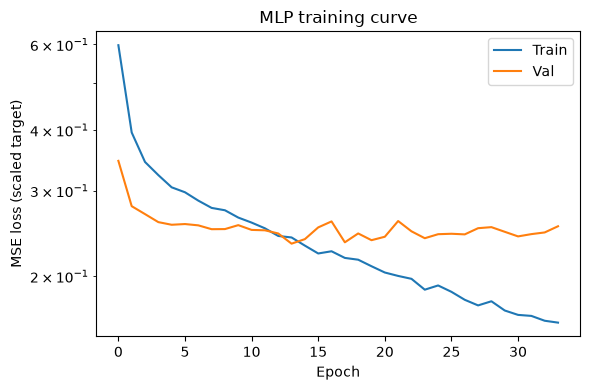

In [184]:
train_ds_j = ResidualDataset(X_train_j, y_train_sj, train_group_ids, train_lookup)
val_ds_j   = ResidualDataset(X_val_j,   y_val_sj,   val_group_ids,   val_lookup)

print("\nTraining end-to-end Encoder+MLP...")
encoder_mlp_model = train_encoder_mlp(train_ds_j, val_ds_j, n_tabular_features=X_train_j.shape[1])


In [185]:
print("Performance:")
_metrics(y[train_idx], predict_db(model, X_train, y_mean, y_std), "train")  #training-set metrics
_metrics(y[test_idx], predict_db(model, X_test, y_mean, y_std), "test")      #held-out test metrics

Performance:
  train  R2=0.7592  RMSE=5.501 dB  MAE=3.392 dB
  test   R2=0.6991  RMSE=6.196 dB  MAE=3.725 dB
